<a href="https://colab.research.google.com/github/fayashi06/Deep-Learning-Classification-/blob/main/DeeplearningTorch2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn

In [ ]:
if torch.cuda.is_available():
  device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
      device = 'cpu'

In [ ]:
import torchvision #hem dataset verir hem de model
import torchvision.transforms.v2 as T

In [ ]:
toTensor = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale = True) # 0 -255 >>>> 0 1
])


In [ ]:
train_and_valid_data = torchvision.datasets.FashionMNIST(
    root = 'datasets',
    train = True,
    download = True,
    transform = toTensor
)
test_data= torchvision.datasets.FashionMNIST(
    root = 'datasets',
    train = False,
    download = True,
    transform = toTensor
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 173kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.15MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.2MB/s]


In [ ]:
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data,
    [55_000, 5_000]
)

In [ ]:
train_data[0]

(Image([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000,

In [ ]:
X_sample,y_sample = train_data[0]

In [ ]:
y_sample

8

In [ ]:
X_sample.shape #1 o demekdir ki rengi bozdur 3 olsa RGB olar [Batch,Channel,Height, Width]

torch.Size([1, 28, 28])

In [ ]:
X_sample.dtype

torch.float32

In [ ]:
train_and_valid_data.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
#mutleq 2 dimension lazimdir

In [ ]:
train_and_valid_data.class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

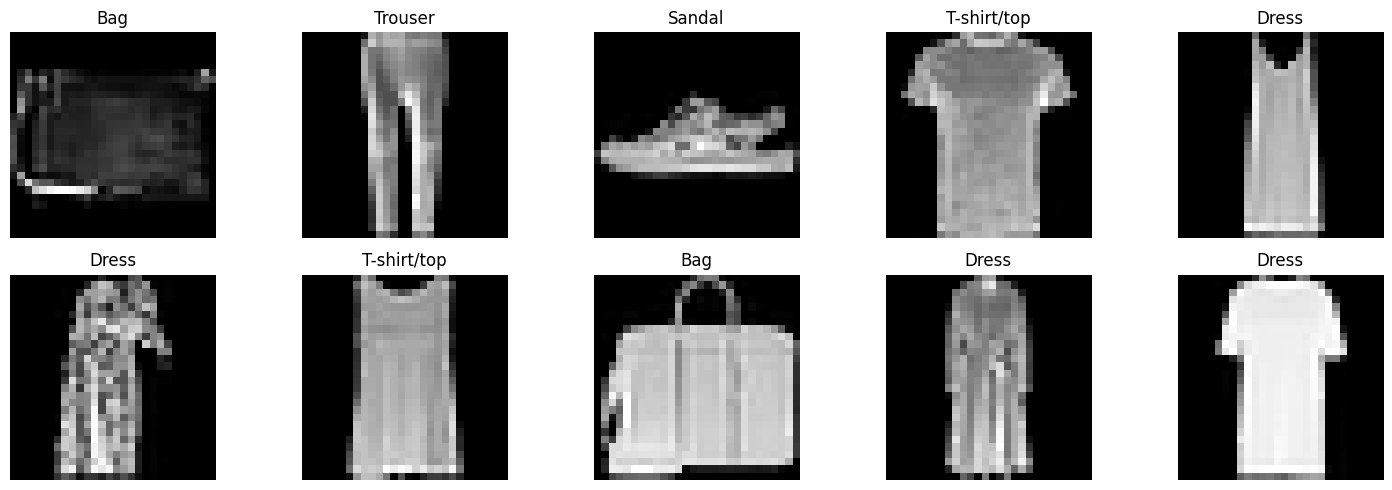

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2,5,figsize = (15,5))

for i, ax in enumerate(axes.flat):   #[x1,x2,x3]>>>> [ x1,x2,x3,x4,x5,x6]
                                      #[x4,x5,x6]


  X, y  = train_data[i]
  ax.imshow(X.squeeze(), cmap = 'gray') # X.squeeze >>>> (1,28,28) >>> (28,28) atdi 1i
  ax.set_title(train_and_valid_data.classes[y])
  ax.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
class ImageClassifier(nn.Module):
  def __init__(self, n_inputs, n_hidden1,n_hidden2,n_classes):
    super().__init__()
    self.mlp = nn.Sequential(
        nn.Flatten(), #[1,28,28] = [1*28*28]
        nn.Linear(n_inputs, n_hidden1),
        nn.ReLU(),
        nn.Linear(n_hidden1, n_hidden2),
        nn.ReLU(),
        nn.Linear(n_hidden2, n_classes)
    )
  def forward(self,X):
   return self.mlp(X)


In [ ]:
torch.manual_seed(42)
model = ImageClassifier(
    n_inputs = 1*28*28,
    n_hidden1 = 300,
    n_hidden2 = 100,
    n_classes = 10

)
model = model.to(device)

In [ ]:
optimizer = torch.optim.SGD(model.parameters(), lr = 0.01)



In [ ]:
criterion = nn.CrossEntropyLoss()

In [ ]:
from torch.utils.data import DataLoader

In [ ]:
train_loader = DataLoader(
    train_data,
    batch_size = 32,
    shuffle = True
)
test_loader = DataLoader(
    test_data,
    batch_size = 32,
    shuffle = False
)
valid_loader = DataLoader(
    valid_data,
    batch_size = 32,
    shuffle = False
)

In [ ]:
!pip install torchmetrics

In [ ]:
import torchmetrics

In [ ]:
accuracy = torchmetrics.Accuracy(
    task = 'multiclass',
    num_classes = 10
).to(device)

In [ ]:
n_epochs = 20
model.train()
for epoch in range(n_epochs):
  total_loss = 0.0
  for X_batch, y_batch in train_loader:
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)


    y_logits = model(X_batch)
    loss = criterion(y_logits, y_batch)

    total_loss += loss.item()

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
mean_loss = total_loss / len(train_loader)
model.eval()
accuracy.reset()
with torch.no_grad():
  for X_batch, y_batch in valid_loader:
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
    y_logits = model(X_batch)
    accuracy.update(y_logits, y_batch)
  val_accuracy = accuracy.compute()
  print(f"epoch{epoch+1}/{n_epochs}, train_loss:{mean_loss:.4}, val_accuracy{val_accuracy:.4}")

epoch20/20, train_loss:0.1674, val_accuracy0.8952


In [ ]:
import torch.nn.functional as F

In [ ]:
model.eval()
X_new, y_new = next(iter(test_loader))
X_new, y_new = X_new[:3].to(device), y_new[:3].to(device)
with torch.no_grad():
    y_logits= model(X_new)
    probas = F.softmax(y_logits, dim=1)
    preds = probas.argmax(dim=1)


In [ ]:
y_logits

tensor([[ -0.7028,  -4.8146,  -3.2442,  -2.5038,  -6.3540,   4.0770,  -3.2375,
           6.2874,   0.9096,  12.4281],
        [  7.4077,  -2.7994,  18.8995,  -1.9738,  11.3996,  -8.2164,   8.4177,
         -15.6329,  -0.1408, -16.1908],
        [  7.0005,  18.8001,   2.1928,   1.7319,   3.3992, -17.4808,  -3.9366,
          -0.1807,  -5.8060,  -6.8936]], device='cuda:0')

In [ ]:
probas

tensor([[1.9784e-06, 3.2401e-08, 1.5580e-07, 3.2669e-07, 6.9505e-09, 2.3559e-04,
         1.5685e-07, 2.1483e-03, 9.9205e-06, 9.9760e-01],
        [1.0208e-05, 3.7676e-10, 9.9941e-01, 8.6017e-10, 5.5282e-04, 1.6730e-12,
         2.8026e-05, 1.0058e-15, 5.3788e-09, 5.7578e-16],
        [7.5076e-06, 9.9999e-01, 6.1312e-08, 3.8670e-08, 2.0487e-07, 1.7514e-16,
         1.3353e-10, 5.7114e-09, 2.0592e-11, 6.9400e-12]], device='cuda:0')

In [ ]:
preds

tensor([9, 2, 1], device='cuda:0')

In [ ]:
y_new

tensor([9, 2, 1], device='cuda:0')